In [ ]:
# ============================================================
#  SKILL-TO-SALARY PREDICTOR — Google Colab
#  Models: Linear Regression, Random Forest,
#          Gradient Boosting, Neural Network (MLP)
# ============================================================

# ── 1. Install & Import ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

print("✅ All libraries imported successfully!")

# ── 2. Synthetic Dataset Generator ───────────────────────────
np.random.seed(42)

SKILLS      = ["Python","ML/AI","SQL","React","Cloud","NLP",
                "System Design","Deep Learning","Kubernetes",
                "Spark","Java","Data Analysis"]
SKILL_BONUS = [12,18,8,10,14,20,16,17,13,11,9,9]   # $K per skill

INDUSTRIES  = ["tech","finance","health","retail","consulting"]
IND_MULT    = [1.15, 1.12, 0.95, 0.85, 1.05]

# Updated locations to Indian cities and remote_india
LOCATIONS   = ["mumbai","bangalore","delhi","chennai","hyderabad","remote_india"]
# Adjusted multipliers for Indian cities (relative to original US_mid base of 1.0 in USD)
LOC_MULT    = [0.30, 0.28, 0.25, 0.22, 0.22, 0.20]

ROLES       = ["junior","mid","senior","lead","manager","exec"]
ROLE_MULT   = [0.70, 1.00, 1.30, 1.45, 1.55, 1.90]

# Define COLORS for plotting (missing from original code)
COLORS = ['#88c0d0', '#5e81ac', '#bf616a', '#d08770', '#ebcb8b', '#a3be8c', '#b48ead']

def generate_dataset(n=500):
    records = []
    for _ in range(n):
        skills     = (np.random.rand(len(SKILLS)) > 0.6).astype(int)
        exp        = np.random.randint(0, 21)
        prof       = np.random.randint(1, 6)
        ind_idx    = np.random.randint(len(INDUSTRIES))
        loc_idx    = np.random.randint(len(LOCATIONS))
        role_idx   = np.random.randint(len(ROLES))

        skill_bonus = sum(s * b * 1000 for s, b in zip(skills, SKILL_BONUS))
        base        = 40_000 + exp * 2_200 + (prof - 1) * 3_500 + skill_bonus
        salary      = int(base
                          * IND_MULT[ind_idx]
                          * LOC_MULT[loc_idx]
                          * ROLE_MULT[role_idx]
                          * np.random.uniform(0.90, 1.10))

        row = {**{f"skill_{s}": v for s, v in zip(SKILLS, skills)},
               "exp": exp, "prof": prof,
               "industry": INDUSTRIES[ind_idx],
               "location": LOCATIONS[loc_idx],
               "role":     ROLES[role_idx],
               "salary":   salary}
        records.append(row)

    df = pd.DataFrame(records)
    df = pd.get_dummies(df, columns=["industry","location","role"])
    return df

df = generate_dataset(500)
print(f"✅ Dataset generated: {df.shape[0]} rows × {df.shape[1]} columns")
print(df.head(3))

# ── 3. Train / Test Split ─────────────────────────────────────
X = df.drop("salary", axis=1)
y = df["salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"\n✅ Train: {len(X_train)} | Test: {len(X_test)}")

# ── 4. Define Models ─────────────────────────────────────────
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  Ridge(alpha=1.0))
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=8,
        min_samples_leaf=3, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.08,
        max_depth=4, subsample=0.8, random_state=42
    ),
    "Neural Network": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42, activation='relu'))
    ])
}

# ── 5. Train & Evaluate ───────────────────────────────────────
results = {}
predictions = {}

print("\n" + "="*55)
print(f"{'Model':<25} {'R²':>8} {'MAE ($K)':>10} {'CV R²':>10}")
print("="*55)

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2    = r2_score(y_test, preds)
    mae   = mean_absolute_error(y_test, preds)
    cv    = cross_val_score(model, X_train, y_train,
                            cv=5, scoring="r2").mean()

    results[name]     = {"R2": r2, "MAE": mae, "CV_R2": cv}
    predictions[name] = preds

    print(f"{name:<25} {r2:>8.4f} {mae/1000:>10.1f} {cv:>10.4f}")

# ── 6. Weighted Ensemble ──────────────────────────────────────
weights    = np.array([v["R2"] for v in results.values()])
weights    = np.clip(weights, 0, None)
weights   /= weights.sum()
ens_preds  = sum(w * p for w, p in zip(weights, predictions.values()))

ens_r2  = r2_score(y_test, ens_preds)
ens_mae = mean_absolute_error(y_test, ens_preds)
results["Ensemble"] = {"R2": ens_r2, "MAE": ens_mae, "CV_R2": None}
print("-"*55)
print(f"{'Ensemble':<25} {ens_r2:>8.4f} {ens_mae/1000:>10.1f} {'(weighted)':>10}")
print("="*55)

# Define USD to INR conversion rate
USD_TO_INR_RATE = 83.0 # Approximate rate as of early 2024

# ── 8. Interactive Predictor ──────────────────────────────────
def predict_salary(your_skills: list,
                   exp_years: int   = 3,
                   proficiency: int = 3,
                   industry: str    = "tech",
                   location: str    = "bangalore", # Updated default location
                   role: str        = "mid"):
    """
    your_skills  : list of skill names from SKILLS list
    exp_years    : 0–20
    proficiency  : 1–5
    industry     : tech | finance | health | retail | consulting
    location     : mumbai | bangalore | delhi | chennai | hyderabad | remote_india
    role         : junior | mid | senior | lead | manager | exec
    """
    # Build a single-row DataFrame matching training columns
    row = {**{f"skill_{s}": (1 if s in your_skills else 0) for s in SKILLS},
               "exp": exp_years, "prof": proficiency}

    for ind in INDUSTRIES:
        row[f"industry_{ind}"] = 1 if ind == industry else 0
    for loc in LOCATIONS:
        row[f"location_{loc}"] = 1 if loc == location else 0
    for r in ROLES:
        row[f"role_{r}"] = 1 if r == role else 0

    input_df = pd.DataFrame([row])[X.columns]   # align columns

    print("\n" + "="*48)
    print("  SALARY PREDICTION RESULTS (INR)")
    print("="*48)
    preds_row = {}
    for name, model in models.items():
        p = model.predict(input_df)[0]
        preds_row[name] = p
        print(f"  {name:<25} ₹{p * USD_TO_INR_RATE:>10,.0f}/yr") # Convert to INR

    weights_arr = np.array([results[n]["R2"]
                             for n in models.keys()])
    weights_arr = np.clip(weights_arr, 0, None)
    weights_arr /= weights_arr.sum()
    ens = sum(w * preds_row[n]
              for w, n in zip(weights_arr, models.keys()))
    print("-"*48)
    print(f"  {'Ensemble':<25} ₹{ens * USD_TO_INR_RATE:>10,.0f}/yr") # Convert to INR
    lo = min(preds_row.values()); hi = max(preds_row.values())
    print(f"  Range: ₹{lo * USD_TO_INR_RATE:,.0f} – ₹{hi * USD_TO_INR_RATE:,.0f}") # Convert to INR
    print("="*48)

    # Mini bar chart
    fig2, ax = plt.subplots(figsize=(8, 3.5))
    fig2.patch.set_facecolor("#0a0a0f")
    ax.set_facecolor("#0f172a")
    all_names = list(preds_row.keys()) + ["Ensemble"]
    all_vals  = list(preds_row.values()) + [ens]
    # Convert all values to INR for the chart
    bars = ax.bar(all_names, [v * USD_TO_INR_RATE / 1000 for v in all_vals],
                  color=COLORS, edgecolor="none", width=0.5)
    ax.set_ylabel("Salary (₹K)", color="#64748b") # Updated label
    ax.set_title("Prediction by Model (INR)", color="#e2e8f0", pad=8) # Updated title
    ax.tick_params(colors="#64748b", labelsize=8)
    plt.xticks(rotation=15)
    for b, v in zip(bars, all_vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+1,
                f"₹{v * USD_TO_INR_RATE / 1000:.0f}K", ha="center", color="#e2e8f0", fontsize=8) # Convert to INR and K
    plt.tight_layout()
    plt.savefig("prediction_result.png", dpi=120,
                bbox_inches="tight", facecolor="#0a0a0f")
    plt.show()

✅ All libraries imported successfully!
✅ Dataset generated: 500 rows × 32 columns
   skill_Python  skill_ML/AI  skill_SQL  skill_React  skill_Cloud  skill_NLP  \
0             0            1          1            0            0          0   
1             0            0          0            1            0          0   
2             1            1          1            0            0          1   

   skill_System Design  skill_Deep Learning  skill_Kubernetes  skill_Spark  \
0                    0                    1                 1            1   
1                    0                    0                 1            0   
2                    0                    0                 0            0   

   ...  location_delhi  location_hyderabad  location_mumbai  \
0  ...           False                True            False   
1  ...           False                True            False   
2  ...           False               False            False   

   location_remote_india  role_

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

Neural Network              0.3652       13.0     0.3567
-------------------------------------------------------
Ensemble                    0.9491        3.0 (weighted)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



📋 Available Skills:
['Python', 'ML/AI', 'SQL', 'React', 'Cloud', 'NLP', 'System Design', 'Deep Learning', 'Kubernetes', 'Spark', 'Java', 'Data Analysis']

Enter skills separated by commas
(Example: Python,SQL,Cloud): python

Enter Experience Years (0-20): 4
Enter Proficiency Level (1-5): 4

🏢 Available Industries:
['tech', 'finance', 'health', 'retail', 'consulting']
Enter Industry: tech

📍 Available Locations (Indian Cities):
['mumbai', 'bangalore', 'delhi', 'chennai', 'hyderabad', 'remote_india']
Enter Location: chennai

👤 Available Roles:
['junior', 'mid', 'senior', 'lead', 'manager', 'exec']
Enter Role: mid

  SALARY PREDICTION RESULTS (INR)
  Linear Regression         ₹   650,522/yr
  Random Forest             ₹ 2,219,602/yr
  Gradient Boosting         ₹ 1,293,217/yr
  Neural Network            ₹   232,892/yr
------------------------------------------------
  Ensemble                  ₹ 1,219,903/yr
  Range: ₹232,892 – ₹2,219,602


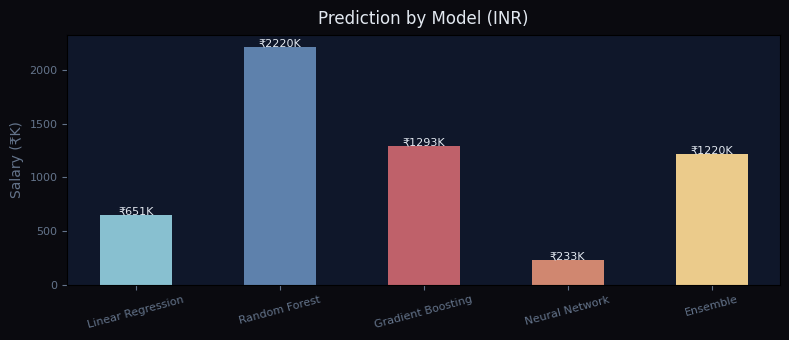

In [9]:
print("\n📋 Available Skills:")
print(SKILLS)

skills_input = input(
    "\nEnter skills separated by commas\n"
    "(Example: Python,SQL,Cloud): "
)

your_skills = [s.strip() for s in skills_input.split(",")]

exp_years = int(input("\nEnter Experience Years (0-20): "))

proficiency = int(input("Enter Proficiency Level (1-5): "))

print("\n🏢 Available Industries:")
print(INDUSTRIES)
industry = input("Enter Industry: ").strip().lower()

print("\n📍 Available Locations (Indian Cities):") # Updated prompt
print(LOCATIONS)
location = input("Enter Location: ").strip().lower()

print("\n👤 Available Roles:")
print(ROLES)
role = input("Enter Role: ").strip().lower()
predict_salary(
    your_skills=your_skills,
    exp_years=exp_years,
    proficiency=proficiency,
    industry=industry,
    location=location,
    role=role
)